# Visualization and evaluation utils

In this file we present how to use some utils to evaluate and visualize AdaBoostFDK results in greater detail.

In [1]:
#First, let's import what's necessary
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold

from utils.evaluation import fl_cross_val_score
from utils.visualization import difference_errorbar_plot,splits_scores_bar_plot,parameter_global_score_overview

In [2]:
#Fix a seed for reproducibility
seed = 242
np.random.seed(seed)

Load the dataset.

Just like in example 1, note that the whole dataset (both train and test) is together. Later, the whole data is distributed among the clients to simulate the federated scenario.

In [3]:
breast_cancer = load_breast_cancer()
X_data = breast_cancer.data
y_data = breast_cancer.target

X_data,public_data,y_data,predicted_public_data = train_test_split(X_data,y_data,train_size=0.95,
                                                                   test_size=0.05,random_state=seed)

In order to get a better understanding of how the AdaBoostFDK models are performing with each parameter, we will train the models 5 times and use cross validation.

Let's first build the data_splits to be used.

In [4]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=seed)
indices_iterable = skf.split(X_data,y_data)

dataset_splits = [None]*5
for i,(filter_train,filter_test) in enumerate(indices_iterable):
    dataset_splits[i] = (X_data[filter_train],X_data[filter_test],
                         y_data[filter_train],y_data[filter_test])

Let's say now we want to compare the performance of AdaBoostFDK according to server_alpha_weight parameter. In order to do so, we fix the other parameters and study the performance of AdaBoostFDK when we change server_alpha_weight parameter. To obtain more robust results, every test is made 5 times (one for each data_split) and are saved for later plots.

In [5]:
#Fixed params
fl_params = {'n_clients':10,
'public_data_prediction':'weighted_majority_voting',
'prediction_weights' :'server_and_clients',
'T' : 10,
'data_distribution': 'niid_dirichlet_label_skew',
'distribution_param' : 0.5,
'random_state': seed}

n_clients = 10
#parameter to study
parameters = ['common_weighted','common_abs','own','avg_abs','avg_weighted']

score_dataframeslist = []
describe_dataframeslist = []
avg_result_list = []
for server_alpha_weight_adj in parameters:
    fl_params['server_alpha_weight_adj'] = server_alpha_weight_adj
    FLmodels,centralized_models,score_dataFrames,describe_dataFrames,centralized_scores,avg_result = fl_cross_val_score(dataset_splits,
                                                                                            public_data,metric='accuracy',fl_params=fl_params)
    score_dataframeslist.append(score_dataFrames)
    describe_dataframeslist.append(describe_dataFrames)
    avg_result_list.append(avg_result)

Once we've trained all we can study the lists of dataframes containing exact results. 

For example, we can see each client's result when using the first parameter ('common_weighted') on the second split.

In [6]:
score_dataframeslist[0][2]

,data_distrib,FL_acc_own_data,FL_acc_global_data,local_acc_own_data,local_acc_global_data,local_difference,global_difference
0,44.0,1.000000,0.962963,1.000000,0.861111,0.00,0.101852
1,33.0,1.000000,0.777778,1.000000,0.629630,0.00,0.148148
2,26.0,1.000000,0.944444,1.000000,0.444444,0.00,0.500000
3,39.0,0.900000,0.916667,0.900000,0.814815,0.00,0.101852
4,12.0,1.000000,0.944444,0.750000,0.907407,0.25,0.037037
5,18.0,1.000000,0.925926,1.000000,0.842593,0.00,0.083333
6,60.0,0.937500,0.768519,0.937500,0.722222,0.00,0.046296
7,41.0,1.000000,0.916667,1.000000,0.814815,0.00,0.101852
8,52.0,0.928571,0.907407,0.928571,0.898148,0.00,0.009259
9,7.0,1.000000,0.944444,1.000000,0.842593,0.00,0.101852


Instead of looking at every client, we can also check the stats associated with that specific split and parameter.

In [7]:
describe_dataframeslist[0][2]

,data_distrib,FL_acc_own_data,FL_acc_global_data,local_acc_own_data,local_acc_global_data,local_difference,global_difference
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,33.200000,0.976607,0.900926,0.951607,0.777778,0.025000,0.123148
std,17.325639,0.038781,0.069434,0.080339,0.143577,0.079057,0.138377
min,7.000000,0.900000,0.768519,0.750000,0.444444,0.000000,0.009259
25%,20.000000,0.953125,0.909722,0.930804,0.745370,0.000000,0.055556
50%,36.000000,1.000000,0.921296,1.000000,0.828704,0.000000,0.101852
75%,43.250000,1.000000,0.944444,1.000000,0.856481,0.000000,0.101852
max,60.000000,1.000000,0.962963,1.000000,0.907407,0.250000,0.500000


It is exactly the same if we do:

In [8]:
score_dataframeslist[0][2].describe()

,data_distrib,FL_acc_own_data,FL_acc_global_data,local_acc_own_data,local_acc_global_data,local_difference,global_difference
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,33.200000,0.976607,0.900926,0.951607,0.777778,0.025000,0.123148
std,17.325639,0.038781,0.069434,0.080339,0.143577,0.079057,0.138377
min,7.000000,0.900000,0.768519,0.750000,0.444444,0.000000,0.009259
25%,20.000000,0.953125,0.909722,0.930804,0.745370,0.000000,0.055556
50%,36.000000,1.000000,0.921296,1.000000,0.828704,0.000000,0.101852
75%,43.250000,1.000000,0.944444,1.000000,0.856481,0.000000,0.101852
max,60.000000,1.000000,0.962963,1.000000,0.907407,0.250000,0.500000


Lastly, if we want a global idea of how the parameter worked in general throughout all the data_splits, we can use the avg_result dataframe, which is an average of all.

In [9]:
avg_result_list[0]

,data_distrib,FL_acc_own_data,FL_acc_global_data,local_acc_own_data,local_acc_global_data,local_difference,global_difference,centralized_scores
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,33.160000,0.951557,0.899815,0.942960,0.797222,0.008597,0.102593,0.924074
std,0.054772,0.042330,0.021669,0.020370,0.028267,0.041522,0.023619,0.020074
min,33.100000,0.901623,0.873148,0.922235,0.775926,-0.028036,0.075926,0.898148
25%,33.100000,0.910373,0.887037,0.929659,0.777778,-0.027159,0.089815,0.916667
50%,33.200000,0.975433,0.900926,0.937532,0.780556,0.001667,0.092593,0.916667
75%,33.200000,0.976607,0.907407,0.951607,0.811111,0.025000,0.123148,0.944444
max,33.200000,0.993750,0.930556,0.973766,0.840741,0.071515,0.131481,0.944444


While the specific dataframes contain a lot of information, it is hard to process it all when the number of parameters and clients increase. Although plots are not enough, they can be of help when finding some possibles weaknesses/strenghts of the proposed algorithm. 

One option is to use an error bar plot to represent the average absolute improvement (for every parameter) of each client (+- std) throughout all data splits, both in local and global tests. Note that the amount of data that each client has is the same in all data splits but the specific instances do change. The higher the number plotted the better the improvement is.

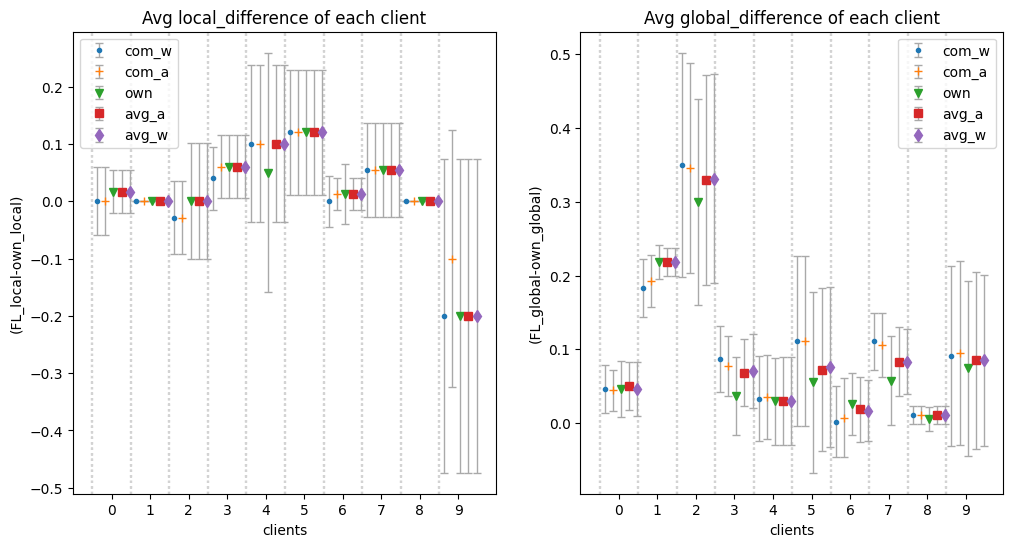

In [10]:
labels=['com_w','com_a','own','avg_a','avg_w']
difference_errorbar_plot(score_frames=score_dataframeslist,
                         labels=labels,n_clients=n_clients)

Another way to visualize how well the algorithm performs is by using a barplot. It represents the average of the results of every client's FL and local model in every data split and for all the parameters considered. It also plots the average across all data splits (The black line on top of each bar is the std). 

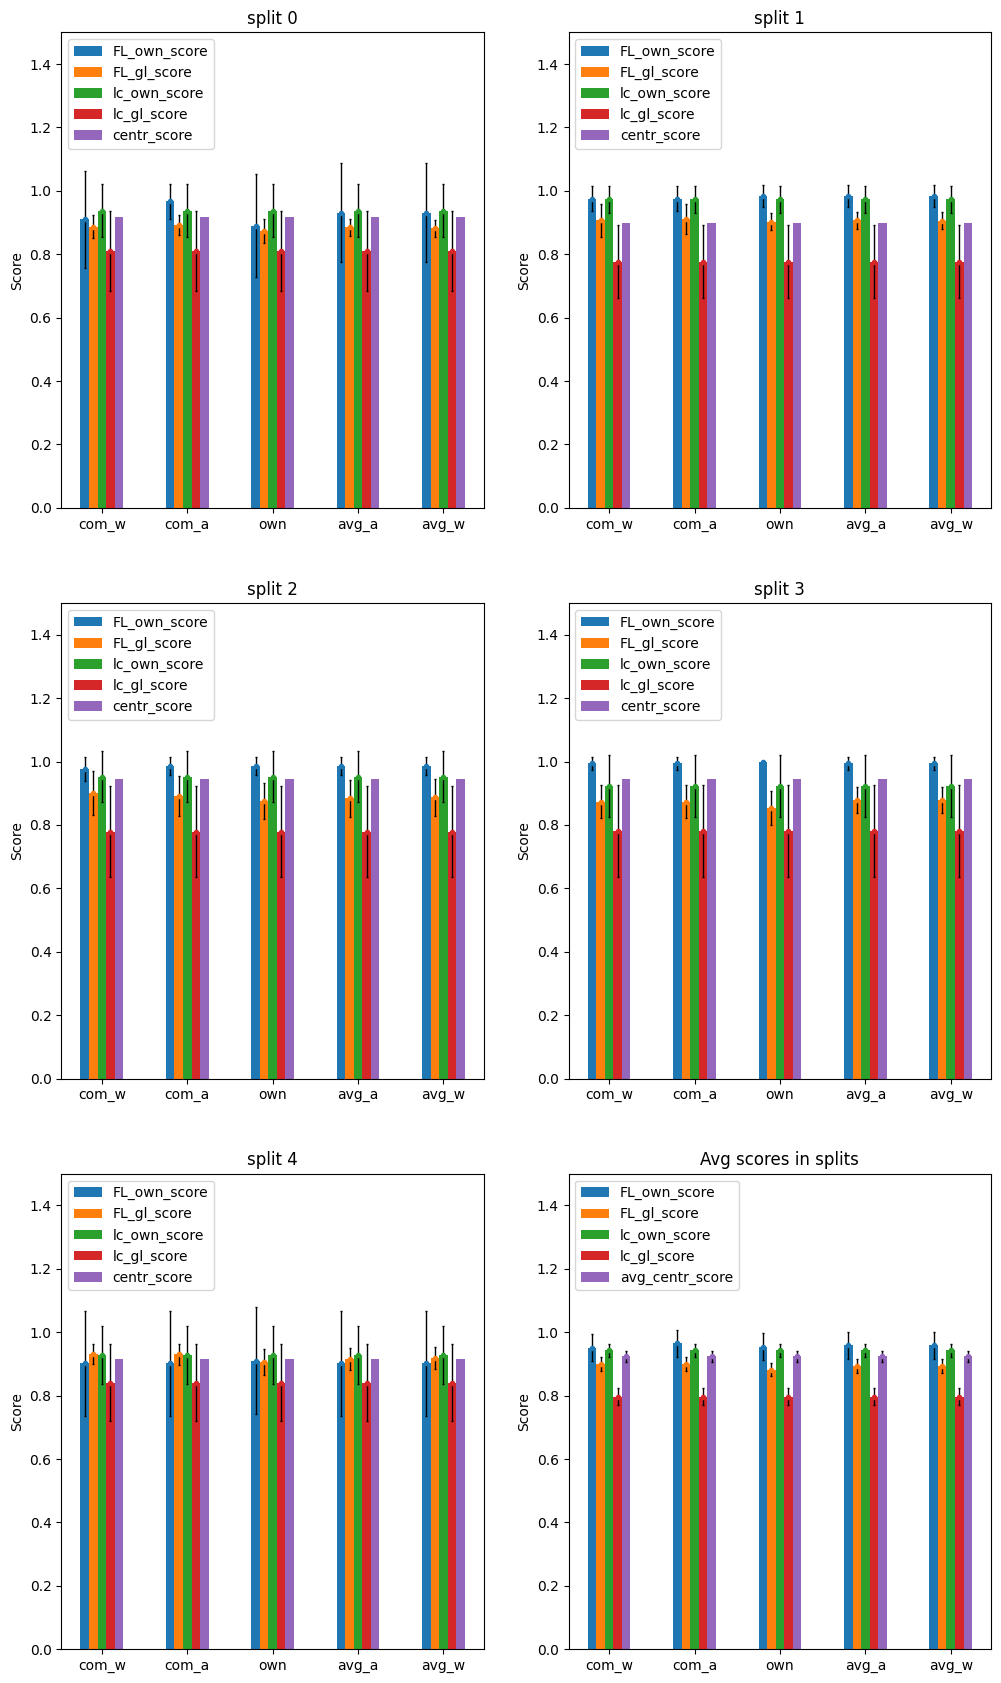

In [11]:
splits_scores_bar_plot(describe_frames=describe_dataframeslist,avg_frames=avg_result_list,centralized_scores=centralized_scores,labels=labels)

Lastly, we can also study how the average performance behaves in every data_split when we change a continuous parameter (for example, T).

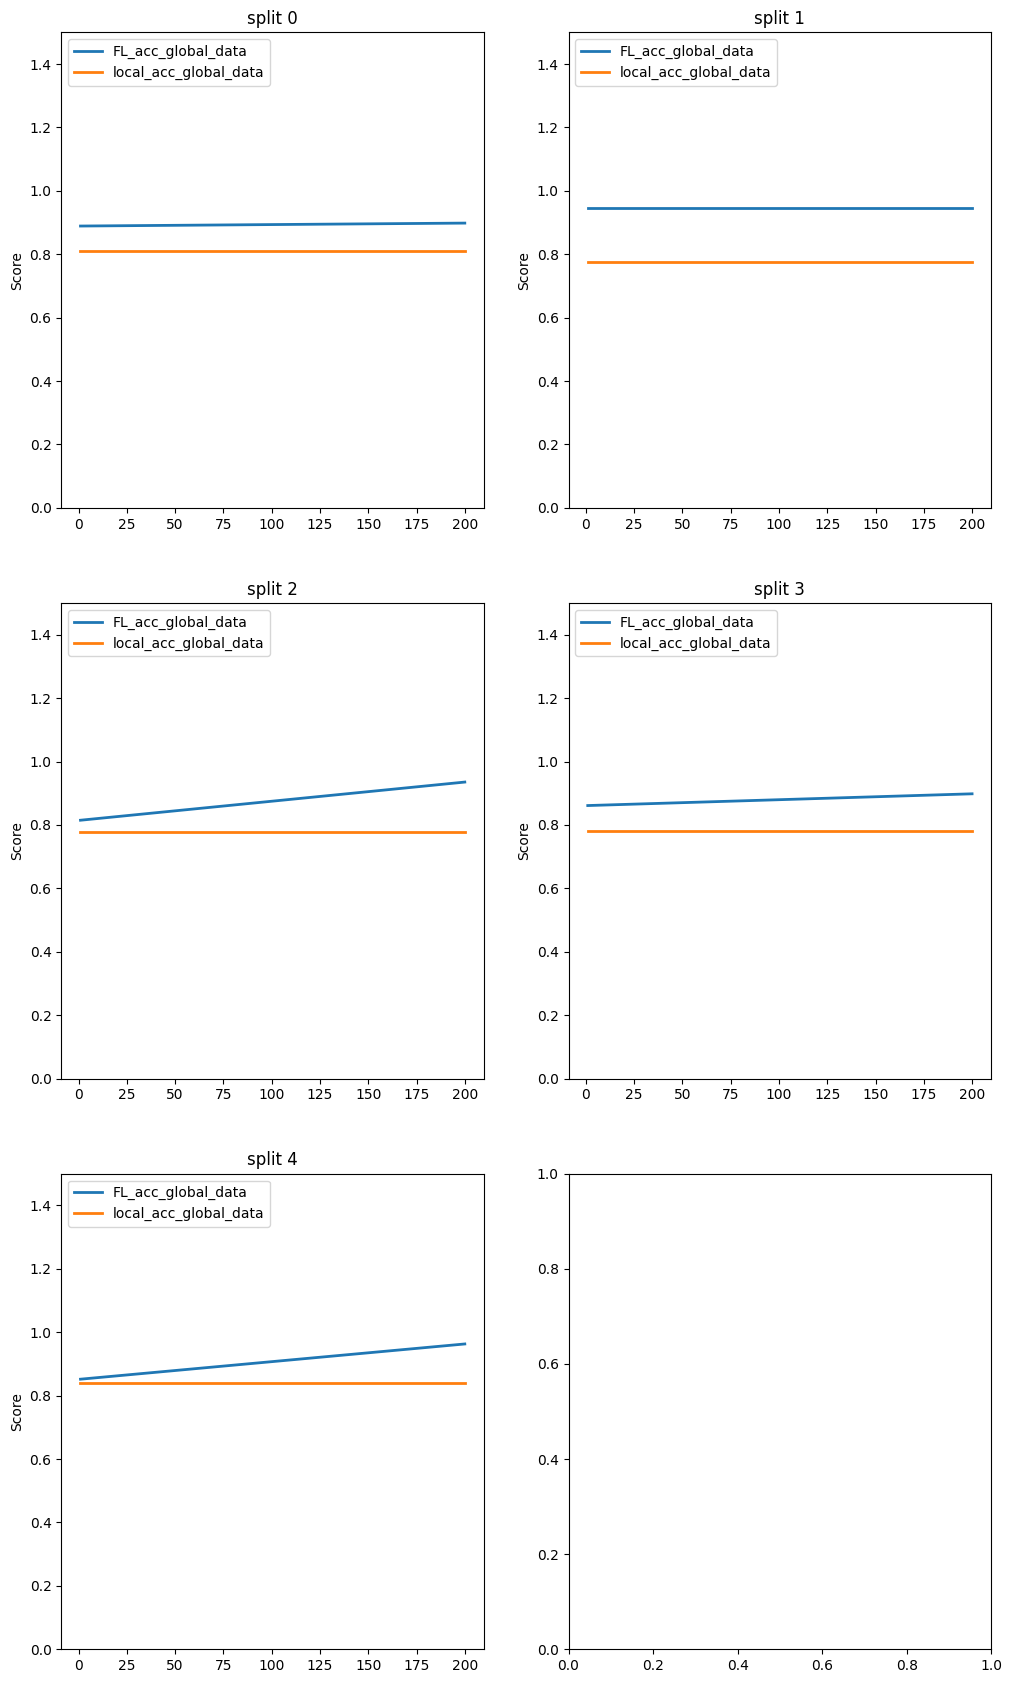

In [15]:
timesteps = np.linspace(1,200,2).astype(int)
splits = {}
fl_params = {'n_clients':10,
'public_data_prediction':'weighted_majority_voting',
'prediction_weights' :'only_server',
'T' : 10,
'data_distribution': 'niid_dirichlet_label_skew',
'distribution_param' : 0.5,
'adapt_client_weight':np.ones(n_clients),
'random_state': seed}

for i,param in enumerate(timesteps):
    fl_params['T'] = param
    FLmodels5,centralized_models5,scoreDataFrames5,describeDataFrames5,centralized_scores5,avgResult5 = fl_cross_val_score(dataset_splits,
                                                                                                    public_data,metric='accuracy',fl_params=fl_params)
    if i == 0:
        for j,dataframe in enumerate(describeDataFrames5):
            splits[j] = [describeDataFrames5[j]]
    else:
        for j,dataframe in enumerate(describeDataFrames5):
            splits[j].append(dataframe)

parameter_global_score_overview(splits,timesteps)